In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [5]:
DATA_DIR = "parking_dataset/clf-data"

empty_path = os.path.join(DATA_DIR, "empty")
not_empty_path = os.path.join(DATA_DIR, "not_empty")

empty_images = [
    f for f in os.listdir(empty_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

not_empty_images = [
    f for f in os.listdir(not_empty_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of empty images:", len(empty_images))
print("Number of not-empty images:", len(not_empty_images))
print("Total images:", len(empty_images) + len(not_empty_images))

Number of empty images: 3045
Number of not-empty images: 3045
Total images: 6090


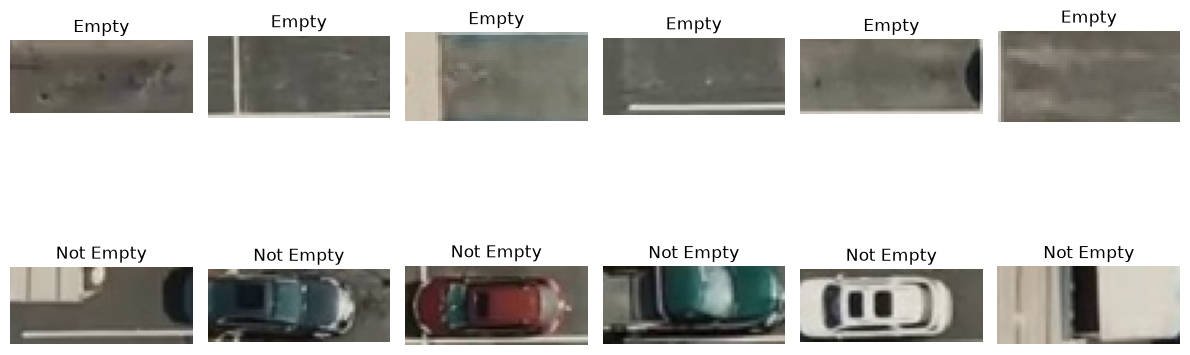

In [6]:
plt.figure(figsize=(12, 6))

# Empty images
for i in range(6):
    image_path = os.path.join(empty_path, empty_images[i])
    image = tf.keras.utils.load_img(image_path)

    plt.subplot(2, 6, i + 1)
    plt.imshow(image)
    plt.title("Empty")
    plt.axis("off")

# Not-empty images
for i in range(6):
    image_path = os.path.join(not_empty_path, not_empty_images[i])
    image = tf.keras.utils.load_img(image_path)

    plt.subplot(2, 6, i + 7)
    plt.imshow(image)
    plt.title("Not Empty")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
sample_path = os.path.join(empty_path, empty_images[0])

sample_image = tf.keras.utils.load_img(sample_path)
sample_array = tf.keras.utils.img_to_array(sample_image)

print("Image shape:", sample_array.shape)

Image shape: (27, 68, 3)


In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["empty", "not_empty"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    shuffle=True
)

Found 6090 files belonging to 2 classes.
Using 4872 files for training.


In [9]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["empty", "not_empty"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    shuffle=True
)

# Number of batches
total_batches = tf.data.experimental.cardinality(temp_ds).numpy()

# Half for validation and half for testing
validation_batches = total_batches // 2

val_ds = temp_ds.take(validation_batches)
test_ds = temp_ds.skip(validation_batches)

print("Dataset successfully split into training, validation and testing sets.")

Found 6090 files belonging to 2 classes.
Using 1218 files for validation.
Dataset successfully split into training, validation and testing sets.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [11]:
def build_model(dropout_rate=0.5, learning_rate=0.001):

    model = models.Sequential([

        # Normalize pixels from 0-255 to 0-1
        layers.Rescaling(1./255, input_shape=(128, 128, 3)),

        # First convolution block
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D(),

        # Second convolution block
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(),

        # Third convolution block
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(),

        # Convert feature maps into a vector
        layers.Flatten(),

        # Fully connected layer
        layers.Dense(128, activation="relu"),

        # Dropout to reduce overfitting
        layers.Dropout(dropout_rate),

        # Binary classification output
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
model = build_model(
    dropout_rate=0.5,
    learning_rate=0.001
)

model.summary()

/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


153/153 ━━━━━━━━━━━━━━━━━━━━ 28s 174ms/step - accuracy: 0.9185 - loss: 0.2053 - val_accuracy: 0.9918 - val_loss: 0.0202
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 29s 187ms/step - accuracy: 0.9959 - loss: 0.0176 - val_accuracy: 0.9967 - val_loss: 0.0093
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.9977 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.9986 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 8.4194e-05
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.9988 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 1.0000 - val_loss: 3.9749e-05
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 27s 176ms/step - accuracy: 1.0000 - loss: 4.0495e-04 - val_accuracy: 1.0000 - val_loss: 3.3641e-06
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.9998 - lo

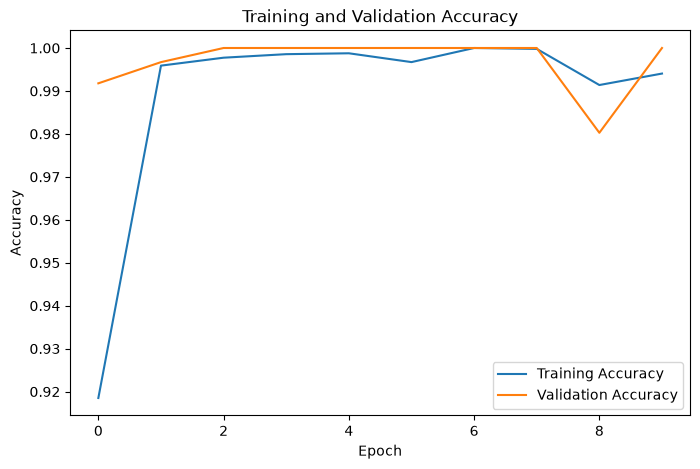

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

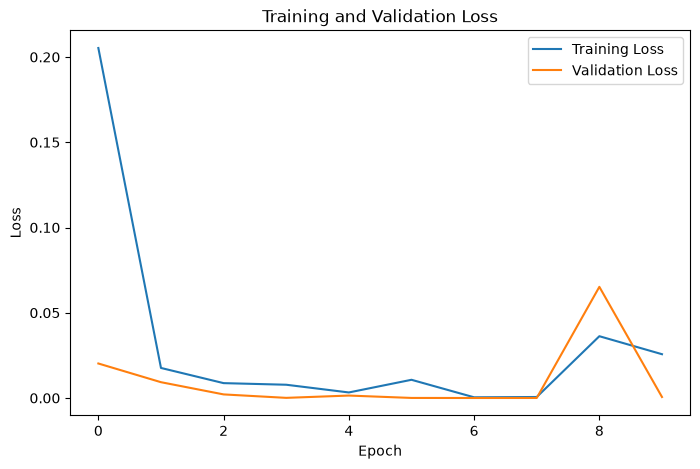

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [16]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(int)

    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [17]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0


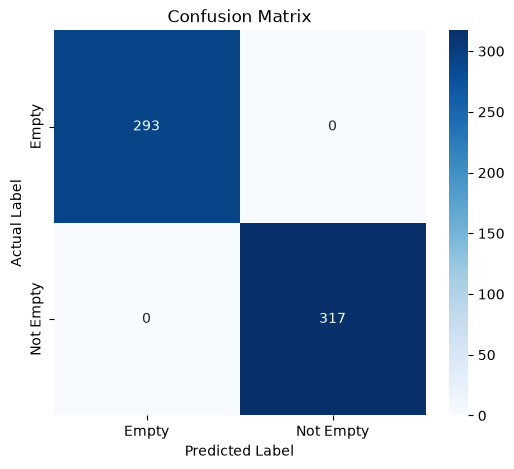

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Empty", "Not Empty"],
    yticklabels=["Empty", "Not Empty"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [19]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Empty", "Not Empty"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00       293
   Not Empty       1.00      1.00      1.00       317

    accuracy                           1.00       610
   macro avg       1.00      1.00      1.00       610
weighted avg       1.00      1.00      1.00       610



In [20]:
def get_metrics(model, dataset):
    
    y_true = []
    y_pred = []

    for images, labels in dataset:
        
        probabilities = model.predict(images, verbose=0).ravel()
        predictions = (probabilities >= 0.5).astype(int)

        y_true.extend(labels.numpy().astype(int).ravel())
        y_pred.extend(predictions)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )

    return accuracy, precision, recall, f1

In [21]:
experiments = [
    {
        "name": "Baseline",
        "learning_rate": 0.001,
        "dropout": 0.50
    },
    {
        "name": "Lower Learning Rate",
        "learning_rate": 0.0001,
        "dropout": 0.50
    },
    {
        "name": "Lower Dropout",
        "learning_rate": 0.001,
        "dropout": 0.30
    }
]

experiment_results = []
trained_models = {}
histories = {}

In [23]:
for experiment in experiments:

    print("=" * 60)
    print("Running:", experiment["name"])
    print("Learning Rate:", experiment["learning_rate"])
    print("Dropout:", experiment["dropout"])
    print("=" * 60)

    exp_model = build_model(
        dropout_rate=experiment["dropout"],
        learning_rate=experiment["learning_rate"]
    )

    exp_history = exp_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1
    )

    # Evaluate on validation data
    val_accuracy, val_precision, val_recall, val_f1 = get_metrics(
        exp_model,
        val_ds
    )

    experiment_results.append({
        "Experiment": experiment["name"],
        "Learning Rate": experiment["learning_rate"],
        "Dropout": experiment["dropout"],
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1
    })

    trained_models[experiment["name"]] = exp_model
    histories[experiment["name"]] = exp_history

    print("\nValidation Results:")
    print("Accuracy :", round(val_accuracy, 4))
    print("Precision:", round(val_precision, 4))
    print("Recall   :", round(val_recall, 4))
    print("F1-score :", round(val_f1, 4))

Running: Baseline
Learning Rate: 0.001
Dropout: 0.5
Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - accuracy: 0.9483 - loss: 0.1482 - val_accuracy: 0.9803 - val_loss: 0.0577
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.9961 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.9951 - loss: 0.0187 - val_accuracy: 0.9984 - val_loss: 0.0029
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9984 - val_loss: 0.0021
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.9967 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 1.7722e-04
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 30s 196ms/step - accuracy: 1.0000 - loss: 7.7699e-04 - val_accuracy: 1.0000 - val_loss: 3.3981e-06
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step - accuracy: 0.9998 - loss: 5.9461e-04 - val_accuracy: 1.0000 - val_loss: 4.4673e-05
Epoch 8/10


/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 218ms/step - accuracy: 0.9278 - loss: 0.2368 - val_accuracy: 0.9918 - val_loss: 0.0600
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step - accuracy: 0.9918 - loss: 0.0306 - val_accuracy: 0.9967 - val_loss: 0.0141
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 220ms/step - accuracy: 0.9967 - loss: 0.0129 - val_accuracy: 0.9984 - val_loss: 0.0033
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 32s 211ms/step - accuracy: 0.9971 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 33s 215ms/step - accuracy: 0.9984 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 6.7662e-04
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 36s 236ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 3.8324e-04
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 220ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 34s 223ms/step - accuracy: 0.9998 - loss: 0.00

/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/jyoya/Desktop/Parking_Space_ Detection /.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


153/153 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.9436 - loss: 0.1542 - val_accuracy: 0.9984 - val_loss: 0.0060
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 228ms/step - accuracy: 0.9957 - loss: 0.0155 - val_accuracy: 0.9984 - val_loss: 0.0029
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 228ms/step - accuracy: 0.9990 - loss: 0.0057 - val_accuracy: 0.9819 - val_loss: 0.0726
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 36s 237ms/step - accuracy: 0.9924 - loss: 0.0260 - val_accuracy: 0.9984 - val_loss: 0.0048
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 35s 232ms/step - accuracy: 0.9957 - loss: 0.0179 - val_accuracy: 1.0000 - val_loss: 9.0473e-05
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 44s 290ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 4.5223e-05
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 78s 508ms/step - accuracy: 1.0000 - loss: 7.3030e-04 - val_accuracy: 1.0000 - val_loss: 8.2856e-06
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 38s 245ms/step - accuracy: 0.9994 - lo

In [24]:
results_df = pd.DataFrame(experiment_results)

results_df = results_df.round(4)

results_df

,Experiment,Learning Rate,Dropout,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,Baseline,0.0010,0.5,1.0,1.0,1.0,1.0
1,Lower Learning Rate,0.0001,0.5,1.0,1.0,1.0,1.0
2,Baseline,0.0010,0.5,1.0,1.0,1.0,1.0
3,Lower Learning Rate,0.0001,0.5,1.0,1.0,1.0,1.0
4,Lower Dropout,0.0010,0.3,1.0,1.0,1.0,1.0


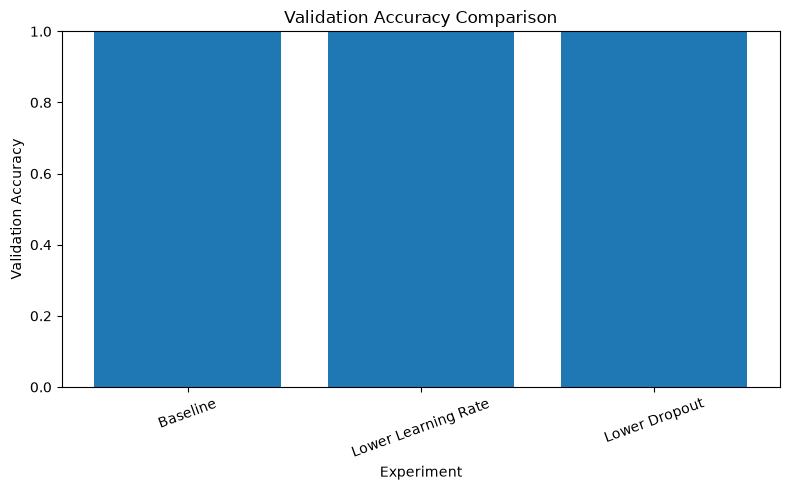

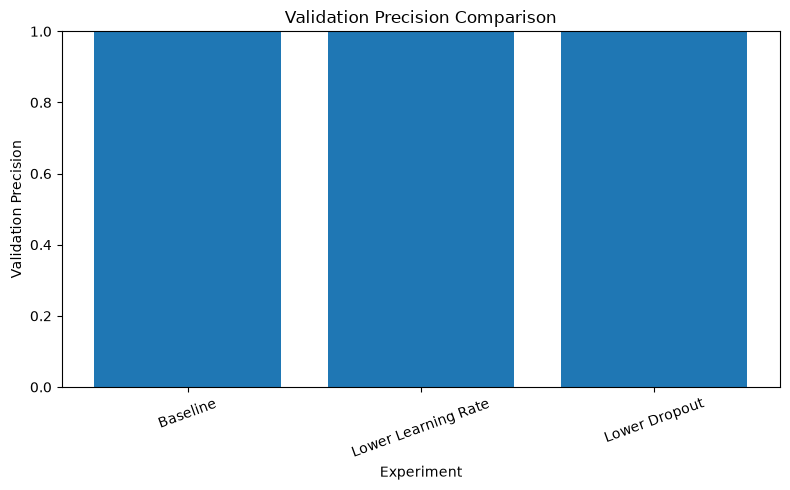

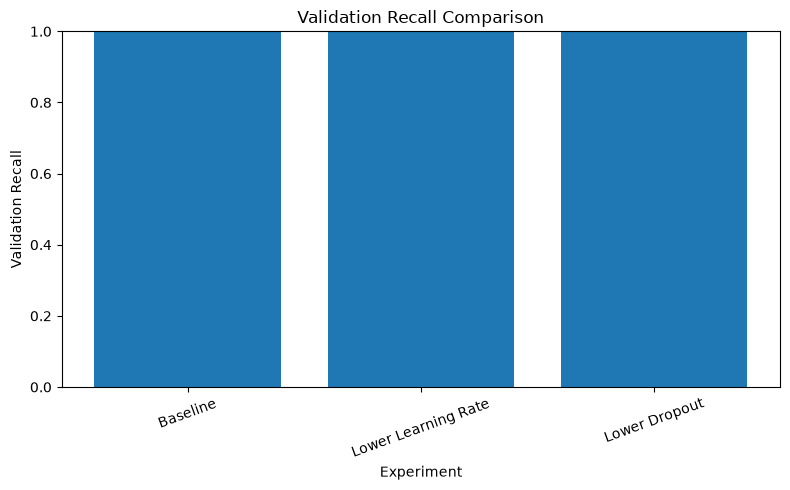

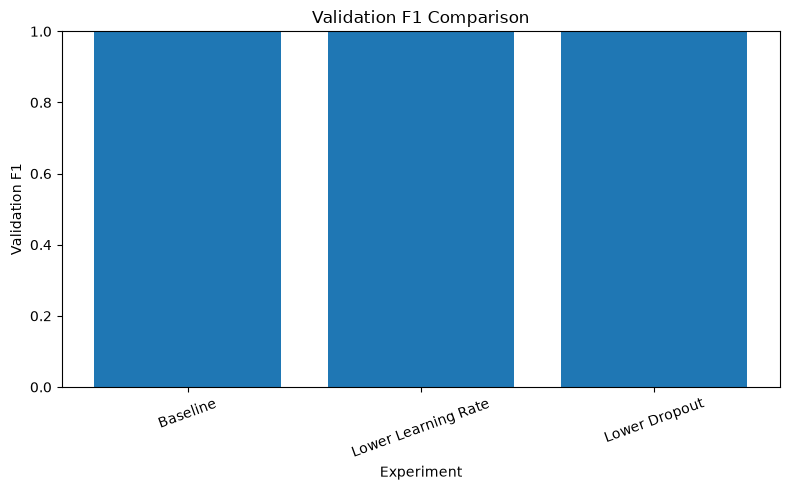

In [25]:
metrics = [
    "Validation Accuracy",
    "Validation Precision",
    "Validation Recall",
    "Validation F1"
]

for metric in metrics:

    plt.figure(figsize=(8, 5))

    plt.bar(
        results_df["Experiment"],
        results_df[metric]
    )

    plt.xlabel("Experiment")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")

    plt.ylim(0, 1)

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

In [26]:
best_index = results_df["Validation F1"].idxmax()

best_experiment = results_df.loc[best_index, "Experiment"]

best_model = trained_models[best_experiment]

print("Selected experiment:", best_experiment)
print(
    "Validation F1-score:",
    results_df.loc[best_index, "Validation F1"]
)

Selected experiment: Baseline
Validation F1-score: 1.0


In [27]:
selected_row = results_df.loc[best_index]

print("Final Model Configuration")
print("-------------------------")
print("Experiment:", selected_row["Experiment"])
print("Learning Rate:", selected_row["Learning Rate"])
print("Dropout:", selected_row["Dropout"])
print("Validation Accuracy:", selected_row["Validation Accuracy"])
print("Validation Precision:", selected_row["Validation Precision"])
print("Validation Recall:", selected_row["Validation Recall"])
print("Validation F1:", selected_row["Validation F1"])

Final Model Configuration
-------------------------
Experiment: Baseline
Learning Rate: 0.001
Dropout: 0.5
Validation Accuracy: 1.0
Validation Precision: 1.0
Validation Recall: 1.0
Validation F1: 1.0


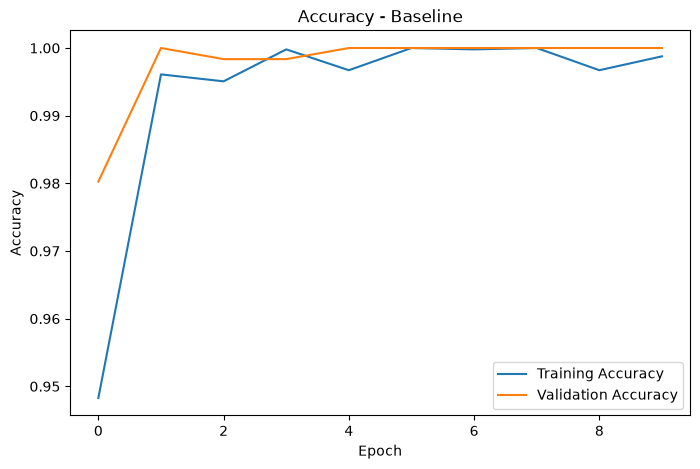

In [28]:
best_history = histories[best_experiment]

plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Accuracy - {best_experiment}")

plt.legend()
plt.show()

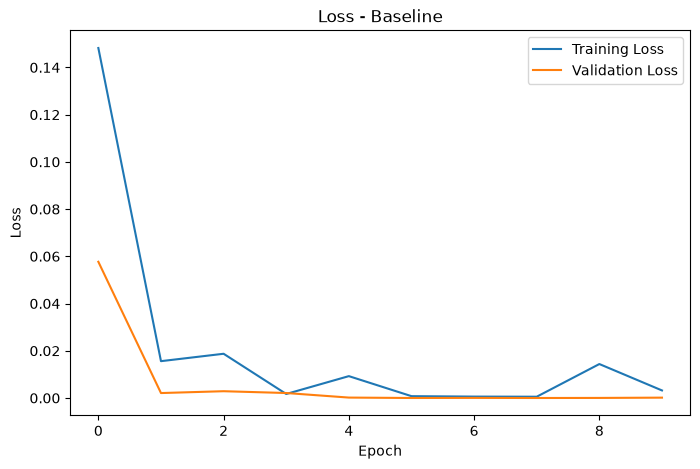

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss - {best_experiment}")

plt.legend()
plt.show()

In [30]:
final_accuracy, final_precision, final_recall, final_f1 = get_metrics(
    best_model,
    test_ds
)

print("FINAL TEST RESULTS")
print("===================")

print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-score :", round(final_f1, 4))

FINAL TEST RESULTS
Accuracy : 0.9984
Precision: 1.0
Recall   : 0.9969
F1-score : 0.9985


In [32]:
y_true_final = []
y_pred_final = []

for images, labels in test_ds:

    probabilities = best_model.predict(
        images,
        verbose=0
    ).ravel()

    predictions = (probabilities >= 0.5).astype(int)

    y_true_final.extend(
        labels.numpy().astype(int).ravel()
    )

    y_pred_final.extend(predictions)

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

final_cm = confusion_matrix(
    y_true_final,
    y_pred_final
)

print(final_cm)

[[295   0]
 [  1 314]]


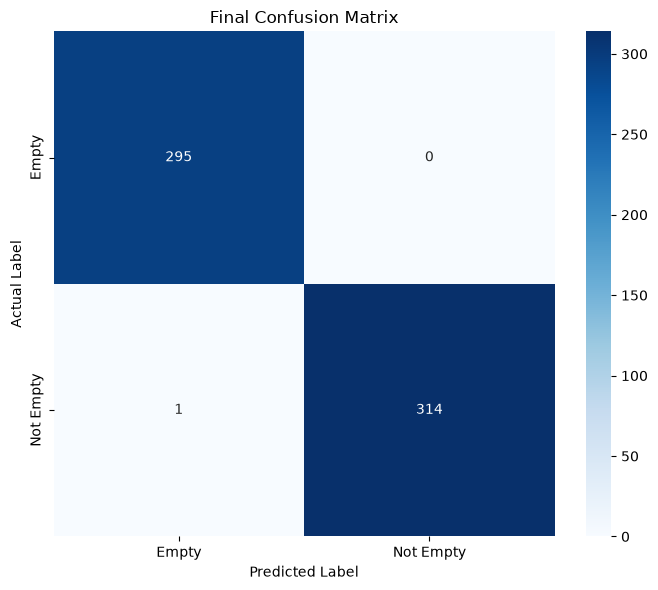

In [33]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Empty", "Not Empty"],
    yticklabels=["Empty", "Not Empty"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Confusion Matrix")

plt.tight_layout()
plt.show()

In [34]:
print(
    classification_report(
        y_true_final,
        y_pred_final,
        target_names=[
            "Empty",
            "Not Empty"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00       295
   Not Empty       1.00      1.00      1.00       315

    accuracy                           1.00       610
   macro avg       1.00      1.00      1.00       610
weighted avg       1.00      1.00      1.00       610



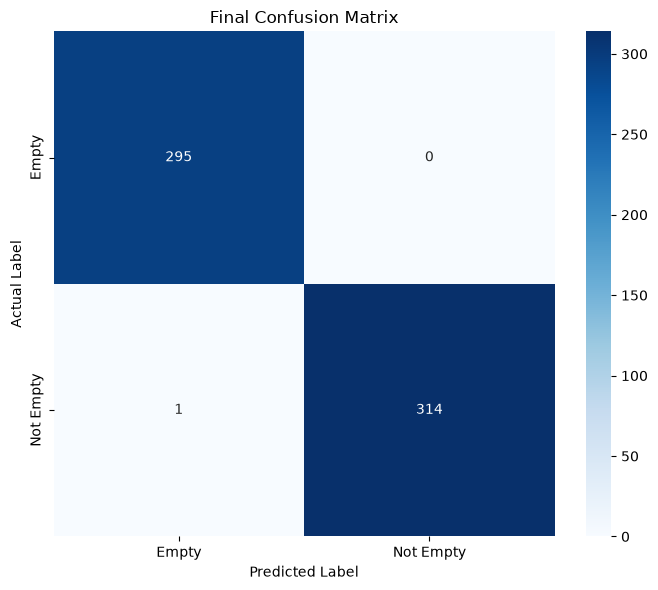

In [35]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Empty", "Not Empty"],
    yticklabels=["Empty", "Not Empty"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

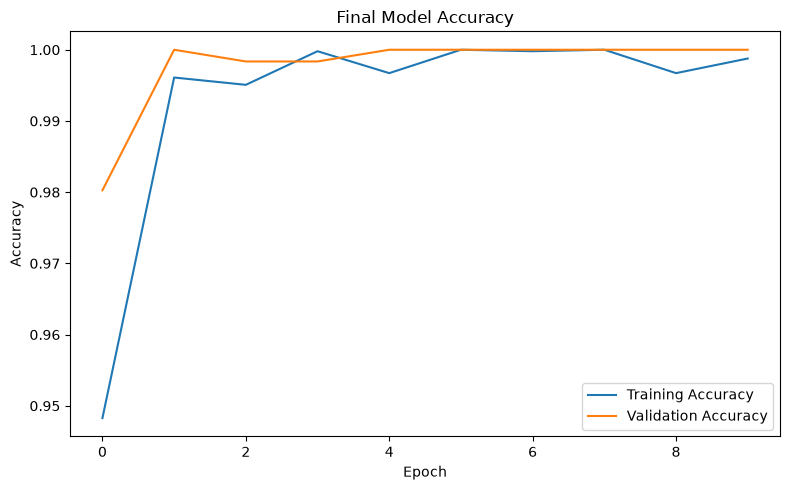

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(
    "final_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

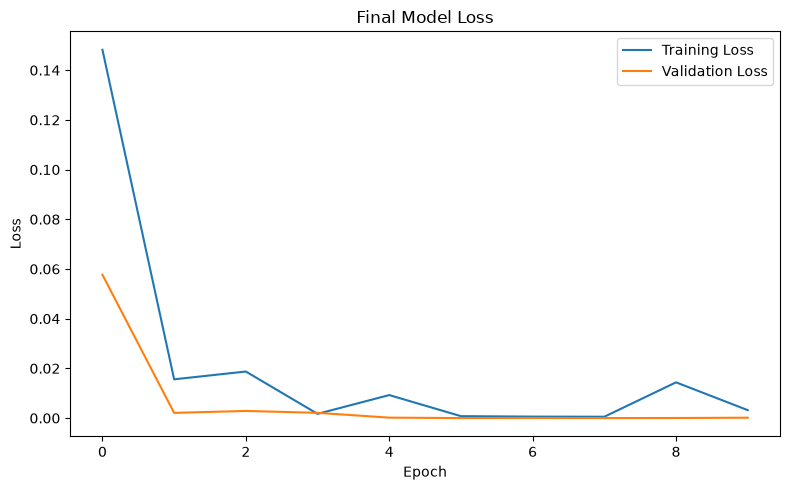

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "final_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
best_model.save("parking_space_cnn.keras")

print("Final CNN model saved successfully.")

Final CNN model saved successfully.


In [39]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_results = final_results.round(4)

final_results

,Metric,Value
0,Accuracy,0.9984
1,Precision,1.0000
2,Recall,0.9969
3,F1-score,0.9985


In [41]:
final_results.to_csv(
    "final_results.csv",
    index=False
)

results_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [42]:
report = classification_report(
    y_true_final,
    y_pred_final,
    target_names=[
        "Empty",
        "Not Empty"
    ],
    zero_division=0
)

with open("classification_report.txt", "w") as file:
    file.write(report)

print("Classification report saved.")

Classification report saved.


In [43]:
print("Files created for the project:")
print()

for file in os.listdir("."):
    if file.endswith((
        ".png",
        ".csv",
        ".txt",
        ".keras"
    )):
        print(file)

Files created for the project:

hyperparameter_results.csv
final_loss.png
parking_space_cnn.keras
final_results.csv
final_confusion_matrix.png
final_accuracy.png
classification_report.txt


In [44]:
print("======================================")
print(" PARKING SPACE CNN - FINAL RESULTS")
print("======================================")

print(f"Selected Model       : {best_experiment}")
print(f"Learning Rate        : {selected_row['Learning Rate']}")
print(f"Dropout              : {selected_row['Dropout']}")
print()
print(f"Test Accuracy        : {final_accuracy:.4f}")
print(f"Test Precision       : {final_precision:.4f}")
print(f"Test Recall          : {final_recall:.4f}")
print(f"Test F1-score        : {final_f1:.4f}")
print("======================================")

 PARKING SPACE CNN - FINAL RESULTS
Selected Model       : Baseline
Learning Rate        : 0.001
Dropout              : 0.5

Test Accuracy        : 0.9984
Test Precision       : 1.0000
Test Recall          : 0.9969
Test F1-score        : 0.9985
